In [146]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [147]:
podcast_episodes_df = pd.read_csv("podcast_episodes.csv")
podcast_listeners_df = pd.read_csv("podcast_listeners.csv")

print(podcast_episodes_df.head())
print(podcast_listeners_df.head())

  episode_id  episode_length_min       genre  num_ads  guest_rating  \
0      EP001                42.3  True Crime        4           2.7   
1      EP002                56.1        Tech        4           4.0   
2      EP003                16.6  True Crime        4           4.9   
3      EP004                58.2     Fiction        0           3.9   
4      EP005                37.4      Comedy        3           4.3   

   host_experience_years  avg_listen_minutes  
0                      4                36.6  
1                      4                38.4  
2                      9                20.1  
3                     10                46.4  
4                      8                27.7  
  listener_id  hours_per_week  num_genres_followed  num_episodes_completed  \
0       L0001             3.2                    3                     7.0   
1       L0002             1.7                    3                     7.0   
2       L0003             4.0                    5       

In [148]:
# print(podcast_episodes_df.info())
# print(podcast_episodes_df.describe())

df_selected_episodes = podcast_episodes_df[
  ["episode_length_min", "num_ads", "guest_rating", "host_experience_years", "avg_listen_minutes"]]

X_episodes = df_selected_episodes[["episode_length_min", "num_ads", "guest_rating", "host_experience_years"]]
y_episodes = df_selected_episodes.iloc[:, -1]

y_episodes

0      36.6
1      38.4
2      20.1
3      46.4
4      27.7
       ... 
215    33.3
216    30.3
217    17.4
218    24.8
219    26.3
Name: avg_listen_minutes, Length: 220, dtype: float64

In [149]:
podcast_listeners_df["is_premium"].value_counts(normalize=True)

is_premium
0    0.502857
1    0.497143
Name: proportion, dtype: float64

In [150]:
X_episodes_train, X_episodes_test, y_episodes_train, y_episodes_test = train_test_split(X_episodes, y_episodes,
                                                                                        test_size=0.2, random_state=42)
model_lr = LinearRegression()
model_lr.fit(X_episodes_train, y_episodes_train)
y_pred = model_lr.predict(X_episodes_test)
mse = mean_squared_error(y_episodes_test, y_pred)
mae = mean_absolute_error(y_episodes_test, y_pred)
r2 = r2_score(y_episodes_test, y_pred)
print(f"MSE: {mse}\nMAE: {mae}\nR2: {r2}")
print("=" * 30)
print(f"model_lr.coef_ = {model_lr.coef_}")

MSE: 22.897516058083035
MAE: 3.9413695490774447
R2: 0.6566868645661039
model_lr.coef_ = [ 0.5723725  -1.20524878  1.96226459  0.25294765]


In [151]:
podcast_listeners_df.drop("listener_id", axis=1, inplace=True)
X_listeners = podcast_listeners_df.iloc[:, :-1]
y_listeners = podcast_listeners_df.iloc[:, -1]

podcast_listeners_df.info()
X_listener_train, X_listener_test, y_listener_train, y_listener_test = train_test_split(X_listeners, y_listeners,
                                                                                        test_size=0.2, random_state=42)
scaler = StandardScaler()
X_listeners_train_scaled = scaler.fit_transform(X_listener_train)
X_listeners_test_scaled = scaler.transform(X_listener_test)


<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hours_per_week          350 non-null    float64
 1   num_genres_followed     350 non-null    int64  
 2   num_episodes_completed  350 non-null    float64
 3   skip_rate_percent       350 non-null    float64
 4   days_since_signup       350 non-null    int64  
 5   is_premium              350 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 16.5 KB


In [152]:
model_logreg = LogisticRegression()
model_logreg.fit(X_listeners_train_scaled, y_listener_train)
y_pred = model_logreg.predict(X_listeners_test_scaled)
report = classification_report(y_listener_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        39
           1       0.71      0.71      0.71        31

    accuracy                           0.74        70
   macro avg       0.74      0.74      0.74        70
weighted avg       0.74      0.74      0.74        70



In [153]:
X_listeners_cl = podcast_listeners_df[["hours_per_week", "num_genres_followed"]]
# print(X_listeners_cl.info())
model_kmeans = KMeans(n_clusters=3, random_state=42)
model_kmeans.fit(X_listeners_cl)
y_pred = model_kmeans.predict(X_listeners_cl)
print(y_pred)


[1 1 2 0 2 0 2 2 2 1 2 0 2 2 2 2 0 1 2 2 2 0 0 2 1 1 0 0 2 2 2 1 2 0 1 2 1
 1 1 2 1 1 1 1 2 1 1 2 0 2 2 0 1 2 2 1 0 2 1 1 2 2 2 2 1 0 0 2 1 2 1 0 2 2
 1 1 2 2 2 0 1 1 2 0 2 2 0 2 1 1 1 1 2 2 1 1 2 0 2 2 1 1 2 1 2 2 2 1 1 2 1
 0 2 2 2 2 1 1 2 0 0 2 1 0 2 1 2 0 1 1 2 2 1 1 1 2 1 2 2 0 1 1 0 2 0 2 1 2
 0 1 1 2 0 1 2 2 2 1 2 1 2 1 1 1 2 2 0 1 1 2 1 1 2 0 2 2 1 2 0 2 2 1 2 1 0
 1 2 2 1 2 0 2 1 0 0 1 0 0 2 2 2 2 1 2 2 1 2 1 2 0 2 2 2 0 1 1 2 2 1 0 1 1
 2 2 0 1 0 1 1 2 2 0 2 0 2 0 2 2 0 0 0 2 2 1 1 0 1 0 0 1 2 0 2 1 1 2 1 1 1
 0 1 2 2 2 0 2 1 2 0 2 2 1 1 1 0 1 2 2 0 1 0 1 0 1 2 1 2 1 0 2 1 0 1 2 1 2
 2 0 1 1 1 2 2 0 1 2 2 0 2 2 0 0 1 2 2 1 2 2 1 2 2 1 2 2 2 2 2 0 2 0 0 2 1
 1 2 2 2 2 2 1 1 2 0 2 2 0 1 0 2 0]


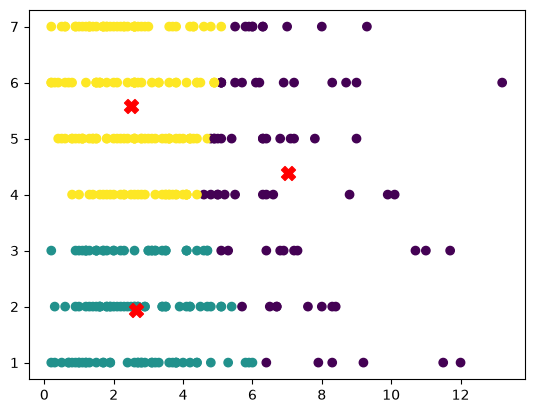

In [154]:

plt.scatter(X_listeners_cl["hours_per_week"], X_listeners_cl["num_genres_followed"], c= y_pred)
plt.scatter(model_kmeans.cluster_centers_[:,0], model_kmeans.cluster_centers_[:,1], c = "red", marker="X", s=100)
plt.show()